In [2]:
import os
from google.colab import files

os.makedirs('/root/.ssh', exist_ok=True)
uploaded = files.upload()   # select corneal_endothelium_image_processing_deploy_key

!mv jk_corneal_endothelium_image_processing_deploy_key /root/.ssh/corneal_endothelium_image_processing_deploy_key
!chmod 600 /root/.ssh/corneal_endothelium_image_processing_deploy_key

ssh_config = """
Host github-corneal-endothelium-image-processing
    HostName github.com
    User git
    IdentityFile /root/.ssh/corneal_endothelium_image_processing_deploy_key
"""
with open('/root/.ssh/config', 'w') as f:
    f.write(ssh_config)
!chmod 600 /root/.ssh/config
!ssh-keyscan github.com >> /root/.ssh/known_hosts 2>/dev/null

REPO_NAME = 'corneal-endothelium-image-processing'
if not os.path.exists(f'/content/{REPO_NAME}'):
    !git clone git@github-corneal-endothelium-image-processing:Jeremy-K-coder/corneal-endothelium-image-processing.git

%cd /content/{REPO_NAME}
!git config --global user.email "jeremykirunda58@gmail.com"
!git config --global user.name "Jeremy Kirunda"
!git pull
print('Repo ready.')

Saving jk_corneal_endothelium_image_processing_deploy_key to jk_corneal_endothelium_image_processing_deploy_key
Cloning into 'corneal-endothelium-image-processing'...
/content/corneal-endothelium-image-processing
Your configuration specifies to merge with the ref 'refs/heads/main'
from the remote, but no such ref was fetched.
Repo ready.


In [10]:
!pwd

/content/corneal-endothelium-image-processing


In [8]:
!mkdir -p analysis_pipeline

### 1. Upload the cornea recording

In [2]:
from google.colab import files

uploaded = files.upload()
video_file = next(iter(uploaded))
print(f"Uploaded: {video_file}")

Saving corneal_recording.mp4 to corneal_recording.mp4
Uploaded: corneal_recording.mp4


### 2. Install and import necessary packages


In [1]:
!pip -q install opencv-python-headless numpy matplotlib scipy pandas scikit-image

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import find_peaks
from skimage.registration import phase_cross_correlation

### 3. Obtain the parameters of the recording and create a single NumPy array of the frames

In [3]:
cap = cv2.VideoCapture(video_file)

n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration_s = n_frames / fps

frames_bgr = []

while True:
    ok, frame = cap.read()
    if not ok:
        break
    frames_bgr.append(frame)

cap.release()

frames_bgr = np.asarray(frames_bgr)

print(f"Frames loaded: {len(frames_bgr)}")
print(f"Dimensions: {width} × {height} pixels")
print(f"Frame rate: {fps:.3f} fps")
print(f"Calculated duration: {duration_s:.3f} seconds")
print(f"Array shape: {frames_bgr.shape}")

Frames loaded: 401
Dimensions: 956 × 680 pixels
Frame rate: 30.000 fps
Calculated duration: 13.367 seconds
Array shape: (401, 680, 956, 3)


### 4. View first, middle and last frame to assess the degree of motion in the video

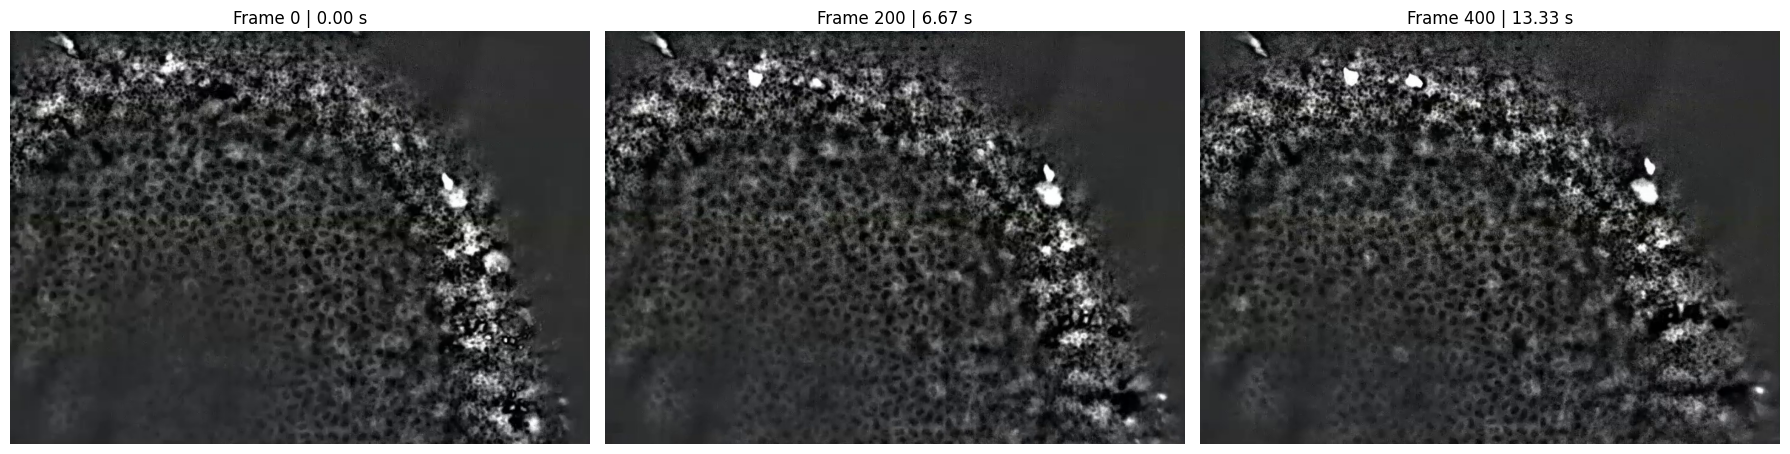

In [4]:
frame_indices = [0, len(frames_bgr) // 2, len(frames_bgr) - 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, index in zip(axes, frame_indices):
    frame_rgb = cv2.cvtColor(frames_bgr[index], cv2.COLOR_BGR2RGB)
    ax.imshow(frame_rgb)
    ax.set_title(f"Frame {index} | {index / fps:.2f} s")
    ax.axis("off")

plt.tight_layout()
plt.show()

### 5. View the red, green and blue channels

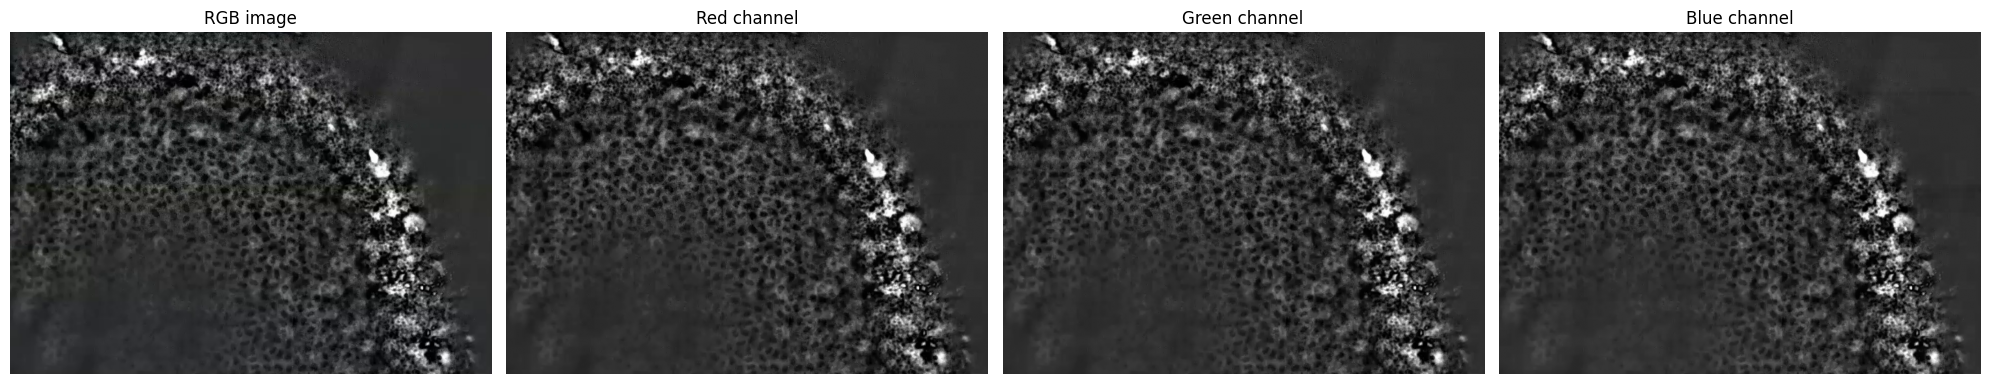

In [5]:
frame_rgb = cv2.cvtColor(frames_bgr[0], cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(frame_rgb)
axes[0].set_title("RGB image")
axes[0].axis("off")

channel_names = ["Red", "Green", "Blue"]

for i, ax in enumerate(axes[1:]):
    ax.imshow(frame_rgb[:, :, i], cmap="gray")
    ax.set_title(f"{channel_names[i]} channel")
    ax.axis("off")

plt.tight_layout()
plt.show()

### 6. Store the green channel of all frames (best image sharpness)

In [6]:
frames = frames_bgr[:, :, :, 1].astype(np.float32)

### 7. Assess the frame displacement relative to the first frame

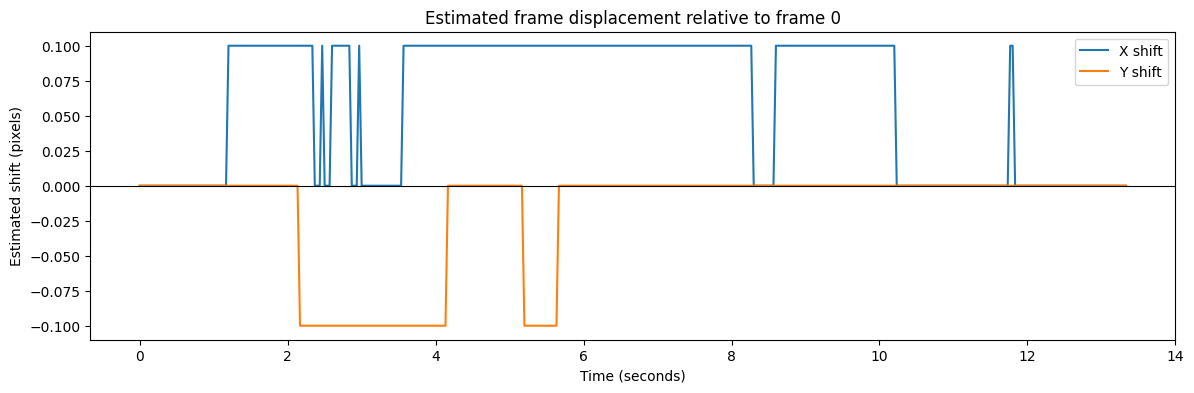

Maximum estimated displacement: 0.10 pixels


In [7]:
reference = frames[0]
shifts = []

for frame in frames:
    shift, error, _ = phase_cross_correlation(
        reference,
        frame,
        upsample_factor=10
    )
    shifts.append(shift)

shifts = np.asarray(shifts)
time_s = np.arange(len(frames)) / fps

plt.figure(figsize=(14, 4))
plt.plot(time_s, shifts[:, 1], label="X shift")
plt.plot(time_s, shifts[:, 0], label="Y shift")
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Time (seconds)")
plt.ylabel("Estimated shift (pixels)")
plt.title("Estimated frame displacement relative to frame 0")
plt.legend()
plt.show()

print(f"Maximum estimated displacement: {np.abs(shifts).max():.2f} pixels")

### 8. Perform motion correction to address the observed shift

In [8]:
from scipy.ndimage import shift as nd_shift

reference = np.median(frames[:30], axis=0)

corrected_frames = np.empty_like(frames)
shifts = []

for i, frame in enumerate(frames):
    shift, error, _ = phase_cross_correlation(
        reference,
        frame,
        upsample_factor=10
    )

    corrected_frames[i] = nd_shift(
        frame,
        shift=shift,
        order=1,
        mode="nearest",
        prefilter=False
    )

    shifts.append(shift)

shifts = np.asarray(shifts)

print("Motion correction complete.")
print(f"Maximum x shift: {np.abs(shifts[:, 1]).max():.2f} pixels")
print(f"Maximum y shift: {np.abs(shifts[:, 0]).max():.2f} pixels")

Motion correction complete.
Maximum x shift: 0.10 pixels
Maximum y shift: 0.10 pixels


### 9. Visually check if motion correction was successful

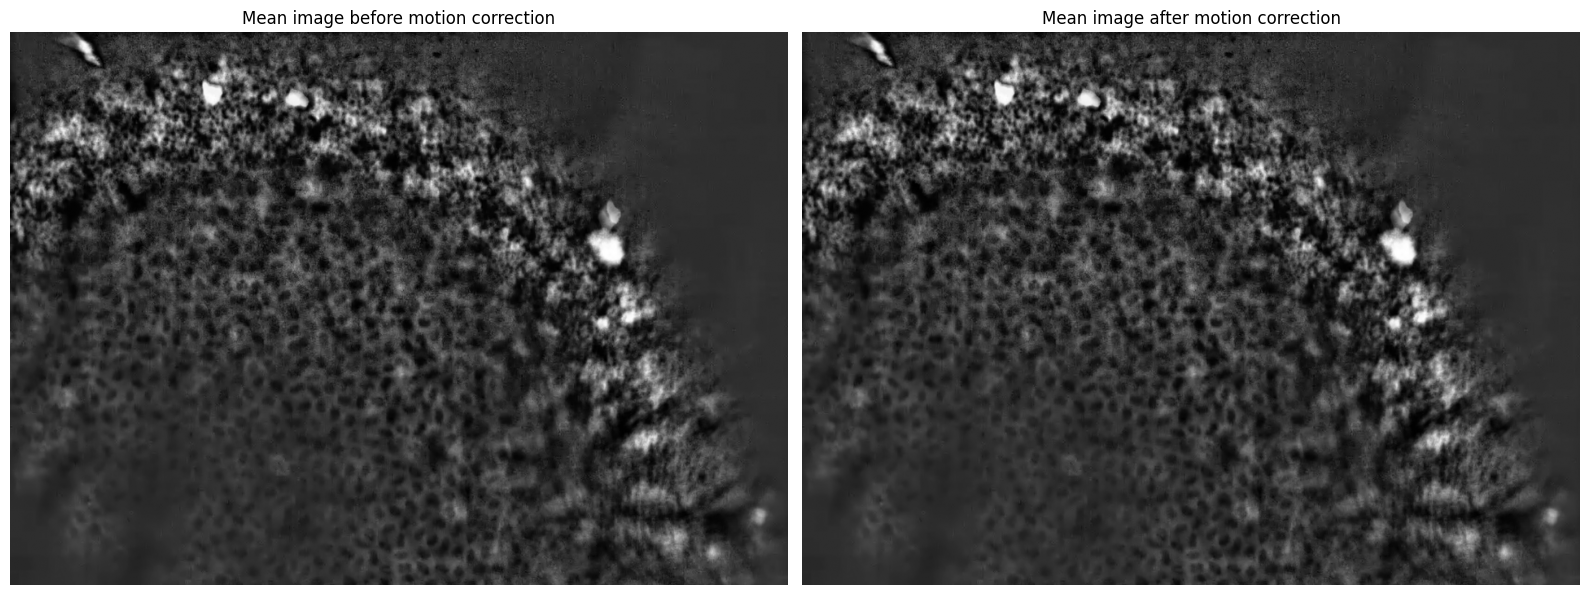

In [9]:
mean_before = np.mean(frames, axis=0)
mean_after = np.mean(corrected_frames, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(mean_before, cmap="gray")
axes[0].set_title("Mean image before motion correction")
axes[0].axis("off")

axes[1].imshow(mean_after, cmap="gray")
axes[1].set_title("Mean image after motion correction")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 10. Crop the corrected frames

In [10]:
max_y_shift = int(np.ceil(np.abs(shifts[:, 0]).max()))
max_x_shift = int(np.ceil(np.abs(shifts[:, 1]).max()))

safe_margin_y = max_y_shift + 5
safe_margin_x = max_x_shift + 5

cropped_frames = corrected_frames[
    :,
    safe_margin_y:-safe_margin_y,
    safe_margin_x:-safe_margin_x
]

print(f"Original shape: {corrected_frames.shape}")
print(f"Cropped shape:  {cropped_frames.shape}")

Original shape: (401, 680, 956)
Cropped shape:  (401, 668, 944)


### 11. Get a sample display frame for manual sample ROI selection

In [11]:
display_frame = np.mean(corrected_frames, axis=0)


### 12. Plot the display frame in interactive format to be able to view x and y values of each pixel

In [12]:
!pip -q install plotly

import plotly.graph_objects as go
import numpy as np

height, width = display_frame.shape

fig = go.Figure(
    data=go.Heatmap(
        z=display_frame,
        colorscale="Gray",
        colorbar=dict(title="Mean intensity"),
        hovertemplate=(
            "x = %{x}<br>"
            "y = %{y}<br>"
            "intensity = %{z:.2f}"
            "<extra></extra>"
        )
    )
)

fig.update_layout(
    title="Interactive motion-corrected reference image",
    width=1000,
    height=750,
    xaxis=dict(
        title="x pixel coordinate",
        range=[0, width],
        constrain="domain"
    ),
    yaxis=dict(
        title="y pixel coordinate",
        range=[height, 0],
        scaleanchor="x",
        scaleratio=1
    )
)

fig.show()

Output hidden; open in https://colab.research.google.com to view.

### 13. Manual cropping to select regions of interest and background (bounding boxes)

In [13]:
cell_id = ("cell_01", "cell_02", "cell_03")
center_x = (480, 320, 423, 478)
center_y = (418, 468, 310, 417)

half_size = 12

cell_rois = {}

for id, x, y in zip(cell_id, center_x, center_y):
    cell_rois[id] = (
        x - half_size,
        x + half_size + 1,
        y - half_size,
        y + half_size + 1
    )

background_roi = (388, 413, 456, 481)

print(cell_rois)

{'cell_01': (468, 493, 406, 431), 'cell_02': (308, 333, 456, 481), 'cell_03': (411, 436, 298, 323)}


### 14. View the image superimposed with the ROI bounding boxes

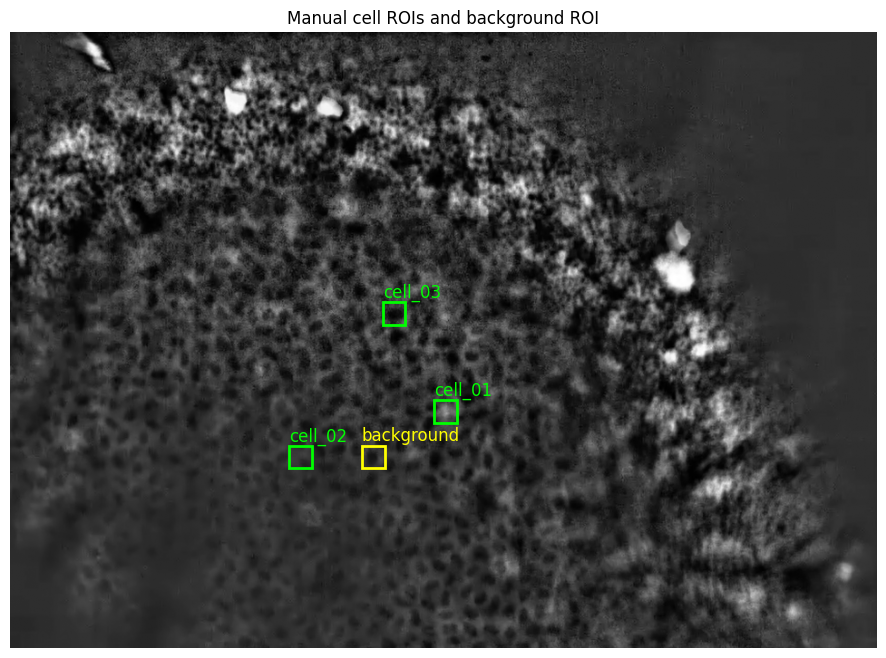

In [14]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(display_frame, cmap="gray")

for cell_name, (x1, x2, y1, y2) in cell_rois.items():
    rectangle = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor="lime", facecolor="none"
    )
    ax.add_patch(rectangle)
    ax.text(x1, y1 - 5, cell_name, color="lime", fontsize=12)

x1, x2, y1, y2 = background_roi
background_rectangle = patches.Rectangle(
    (x1, y1), x2 - x1, y2 - y1,
    linewidth=2, edgecolor="yellow", facecolor="none"
)
ax.add_patch(background_rectangle)
ax.text(x1, y1 - 5, "background", color="yellow", fontsize=12)

ax.set_title("Manual cell ROIs and background ROI")
ax.axis("off")
plt.show()

### 15. Create dataframe with raw and background corrected trace signals for ROIs

In [15]:
def roi_trace(video, roi):
    x1, x2, y1, y2 = roi
    return video[:, y1:y2, x1:x2].mean(axis=(1, 2))

background_trace = roi_trace(corrected_frames, background_roi)

raw_traces = {}
corrected_traces = {}

for cell_name, roi in cell_rois.items():
    raw = roi_trace(corrected_frames, roi)
    raw_traces[cell_name] = raw
    corrected_traces[cell_name] = raw - background_trace

trace_df = pd.DataFrame({
    "time_s": time_s,
    "background": background_trace
})

for cell_name in cell_rois:
    trace_df[f"{cell_name}_raw"] = raw_traces[cell_name]
    trace_df[f"{cell_name}_background_corrected"] = corrected_traces[cell_name]

trace_df.head()

,time_s,background,cell_01_raw,cell_01_background_corrected,cell_02_raw,cell_02_background_corrected,cell_03_raw,cell_03_background_corrected
0,0.000000,51.246399,73.849602,22.603203,47.990398,-3.256001,42.604801,-8.641598
1,0.033333,51.193600,73.838402,22.644802,47.945599,-3.248001,42.601601,-8.591999
2,0.066667,51.129601,73.862396,22.732796,47.903999,-3.225601,42.620800,-8.508801
3,0.100000,51.126400,73.862396,22.735996,47.903999,-3.222401,42.563202,-8.563198
4,0.133333,51.004799,73.804802,22.800003,47.894402,-3.110397,42.535999,-8.468800


### 16. Visualize background-corrected and normalized fluorescence traces, against baseline, for each ROI over time

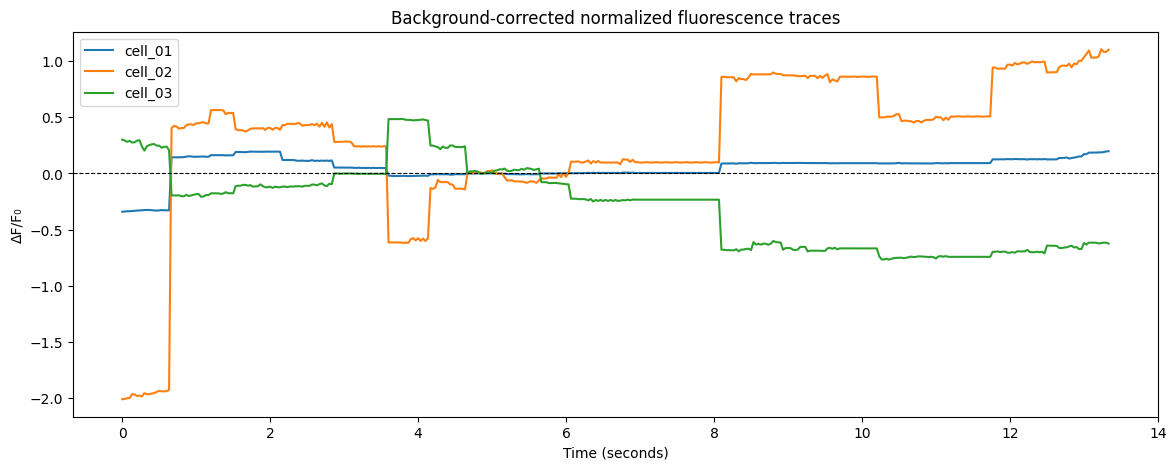

In [16]:
dff_traces = {}

for cell_name, trace in corrected_traces.items():
    F0 = np.percentile(trace, 20)
    dff = (trace - F0) / F0
    dff_traces[cell_name] = dff
    trace_df[f"{cell_name}_dff"] = dff

plt.figure(figsize=(14, 5))

for cell_name, dff in dff_traces.items():
    plt.plot(time_s, dff, linewidth=1.5, label=cell_name)

plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.xlabel("Time (seconds)")
plt.ylabel("ΔF/F₀")
plt.title("Background-corrected normalized fluorescence traces")
plt.legend()
plt.show()

### 17. Visualize candidate events for each ROI cell (Event detection)

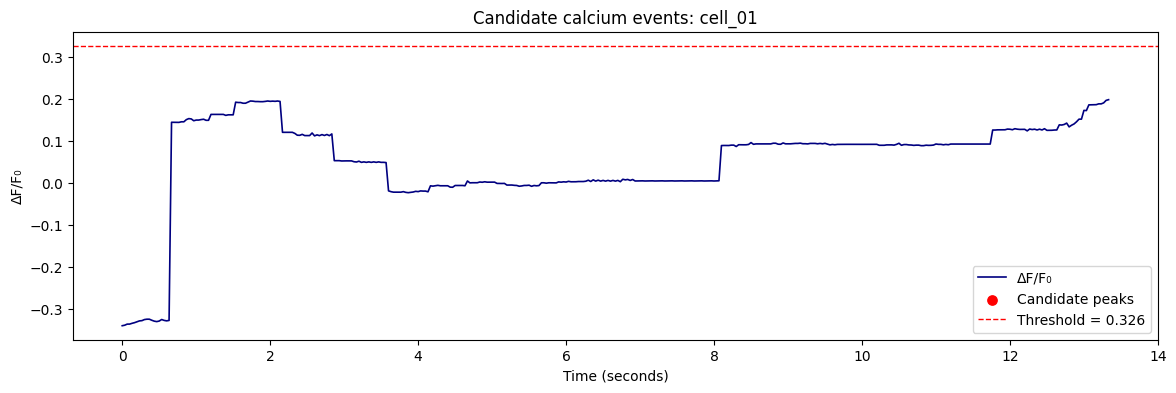

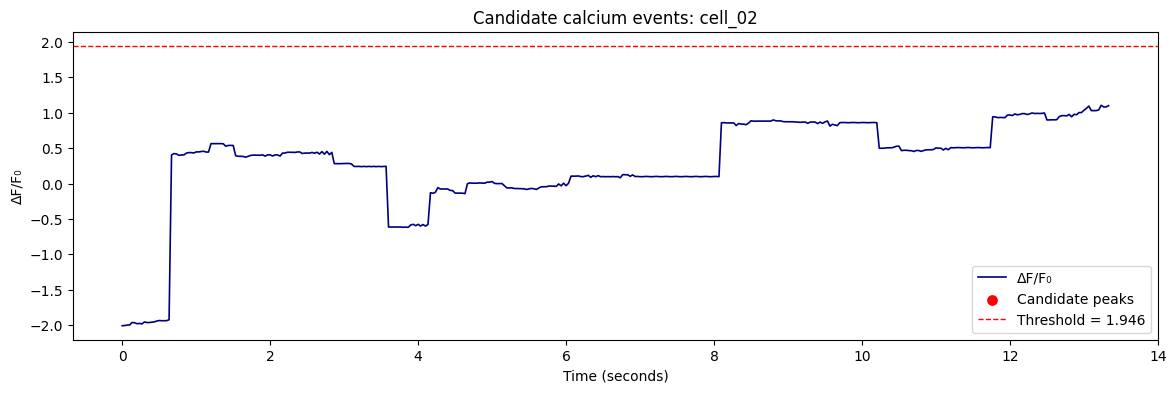

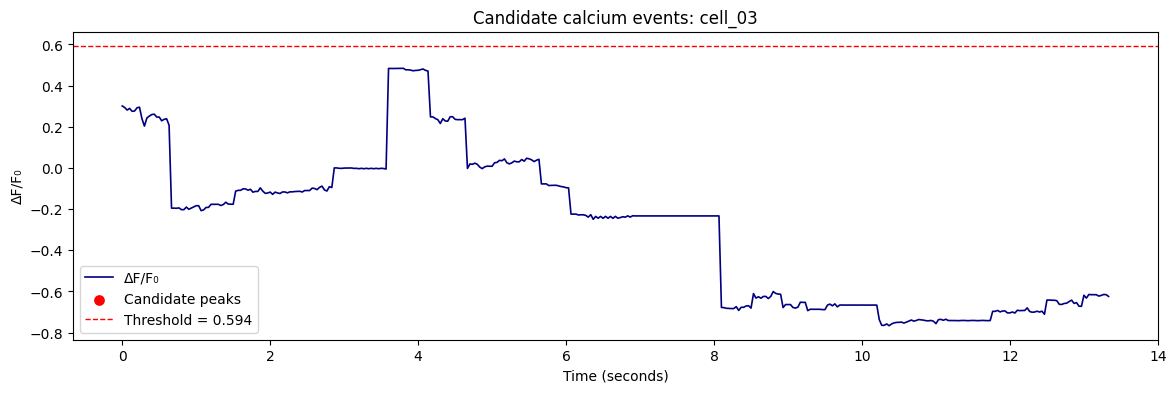

""


In [17]:
event_rows = []

for cell_name, dff in dff_traces.items():
    noise_estimate = np.std(dff[dff <= np.percentile(dff, 50)])
    threshold = max(0.02, 3 * noise_estimate)

    peaks, properties = find_peaks(
        dff,
        height=threshold,
        prominence=threshold / 2,
        distance=max(1, int(0.20 * fps))
    )

    plt.figure(figsize=(14, 4))
    plt.plot(time_s, dff, color="navy", linewidth=1.2, label="ΔF/F₀")
    plt.scatter(
        time_s[peaks], dff[peaks],
        color="red", s=45, zorder=3,
        label="Candidate peaks"
    )
    plt.axhline(
        threshold, color="red",
        linestyle="--", linewidth=1,
        label=f"Threshold = {threshold:.3f}"
    )
    plt.xlabel("Time (seconds)")
    plt.ylabel("ΔF/F₀")
    plt.title(f"Candidate calcium events: {cell_name}")
    plt.legend()
    plt.show()

    for peak in peaks:
        event_rows.append({
            "cell_id": cell_name,
            "peak_frame": int(peak),
            "peak_time_s": time_s[peak],
            "peak_dff": dff[peak],
            "threshold_dff": threshold
        })

event_df = pd.DataFrame(event_rows)
event_df

### 18. Created scenario out of curiosity to see what detected events would look like

Candidate peaks found: 56


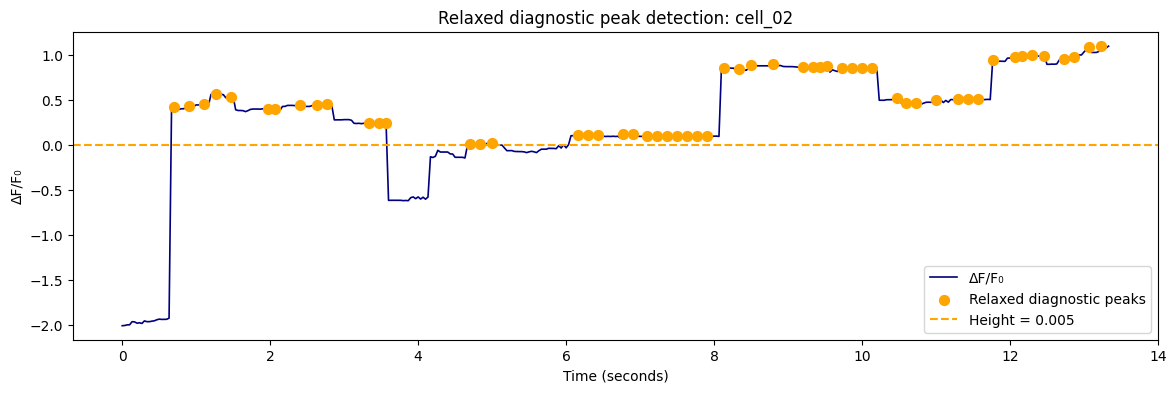

In [18]:
cell_name = "cell_02"
dff = dff_traces[cell_name]

diagnostic_height = 0.005       # 0.5% ΔF/F₀
diagnostic_prominence = 0.003   # 0.3% ΔF/F₀
diagnostic_distance = 3         # 3 frames = 0.10 s at 30 fps

peaks, properties = find_peaks(
    dff,
    height=diagnostic_height,
    prominence=diagnostic_prominence,
    distance=diagnostic_distance
)

print(f"Candidate peaks found: {len(peaks)}")

plt.figure(figsize=(14, 4))
plt.plot(time_s, dff, color="navy", linewidth=1.2, label="ΔF/F₀")
plt.scatter(
    time_s[peaks],
    dff[peaks],
    color="orange",
    s=50,
    zorder=3,
    label="Relaxed diagnostic peaks"
)
plt.axhline(
    diagnostic_height,
    color="orange",
    linestyle="--",
    label=f"Height = {diagnostic_height:.3f}"
)
plt.xlabel("Time (seconds)")
plt.ylabel("ΔF/F₀")
plt.title(f"Relaxed diagnostic peak detection: {cell_name}")
plt.legend()
plt.show()

### 19. Save trace and event data for downstream signal dynamics analysis

In [19]:
trace_df.to_csv("demo_fluorescence_traces.csv", index=False)
event_df.to_csv("demo_candidate_events.csv", index=False)

from google.colab import files

files.download("demo_fluorescence_traces.csv")
files.download("demo_candidate_events.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Copy notebook from Colab to repo, commit and push


import shutil
from pathlib import Path

REPO_DIR = "/content/corneal-endothelium-image-processing/analysis_pipeline"
NB_NAME  = "proof_of_concept_cornea_image_processing_pipeline.ipynb"
COLAB_NB = Path(f"/content/drive/MyDrive/Colab Notebooks/{NB_NAME}")
REPO_NB  = Path(REPO_DIR) / NB_NAME
REPO_NB.parent.mkdir(parents=True, exist_ok=True)

if COLAB_NB.exists():
    shutil.copy(COLAB_NB, REPO_NB)
    print(f"Copied → {REPO_NB}")

assert REPO_NB.exists(), f"Copy failed: {REPO_NB} not found"

%cd {REPO_DIR}
!git add notebooks/ figures/ data/processed/cleaned.pkl
!git status
!git commit -m "Pushed demo pipeline to repo"
!git push
print("Done, demo pipeline committed and pushed.")

Copied → /content/corneal-endothelium-image-processing/analysis_pipeline/proof_of_concept_cornea_image_processing_pipeline.ipynb
/content/corneal-endothelium-image-processing/analysis_pipeline
fatal: pathspec 'notebooks/' did not match any files
On branch main

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	./

nothing added to commit but untracked files present (use "git add" to track)
On branch main

Initial commit

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	./

nothing added to commit but untracked files present (use "git add" to track)
error: src refspec refs/heads/main does not match any
error: failed to push some refs to 'github-corneal-endothelium-image-processing:Jeremy-K-coder/corneal-endothelium-image-processing.git'
Done, demo pipeline committed and pushed.
